# Summary on using Transformer-based AEs to compress gLV data

Author: Zhengqing Zhou
Updated: 2026/05/31

In this notebook, we use transformer-based autoencoders to compress gLV data in "fixed" and "random" simulations.

> ### Reproducibility &amp; data
>
> This notebook reproduces the transformer-baseline FUV figures from the in-repo `saved_data/` caches. Retraining needs the weights + gLV sims from Zenodo.
>
> Notebook **outputs are preserved**, so the results are visible without rerunning. Figure-saving (`savefig`) is disabled for the release; plots still render inline. See the repository `DATA.md` for how to restore Zenodo artifacts.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import trange
from torch.nn import functional as F
from torch import nn
from sklearn.metrics import r2_score

import pickle
import os
from TransformerAE import *

# Configure GPU if available
if torch.cuda.is_available():

    device = "cuda:0"
else:
    device = "cpu"

display(device)

'cuda:0'

# Effective dimension of observable dynamics within a 100-member microbiome

**to calculate the FUV, code below this point requires downloading the entire dataset from Zenodo; but statistical analysis can be performed with `saved_data` folder.**

We define a function *get_error* which will return the MSE loss of the reconstruction of a *n_background*, *n_target* population (simulated with *gLV_type* dynamic model) using an *n_embedding* dimensional VAE model. By iterating through all the parameters, we can then determine the essential dimensionality for the reconstruction of a given size target population dynamics.


In [3]:
def get_error(model,batch,):
    model.to("cuda:0");
    model.eval()
    with torch.no_grad():
        reconstruction,_ = model(batch.to("cuda:0"))
        reconstruction = reconstruction.cpu()
        mse = F.mse_loss(batch,reconstruction)
        r2 = r2_score(batch.flatten(), reconstruction.flatten())
    return mse,r2

In [4]:
from scipy.optimize import curve_fit

def y_exp(x,a,b,c):
    yy = -b*(x-a)
    yy[x>a]=0
    y = c*np.exp(yy)
    return y

## Bounded gLV

### Fixed background case
Call the trained models to determine the MSE, KL divergence, and the R2 of each embedding

> ⚠️ **Requires Zenodo artifacts.** The cell(s) below reload trained models (`torch.load` / `load_state_dict`) or heavy arrays. To reproduce the published figure *without* a download, skip to the plotting cells that read the in-repo `.txt` caches. Restore artifacts first with `zenodo/zenodo_download.sh` (see `DATA.md`).

In [5]:
import os
n_ori=100

glv_type="b"
sim_type="fixed"

NT=np.arange(2,11,1)
N_EBD = [1,2,3,5,6,8,10,12,15,20]
for i,n_target in enumerate(NT):
    n_background=n_ori-n_target
    for model_index in [1,2,3]:
        data_train = np.zeros((6,len(N_EBD)))
        data_train[0,:] = N_EBD
        data_test = np.zeros((6,len(N_EBD)))
        data_test[0,:] = N_EBD
        X_train, X_test = get_data(n_background, n_target, glv_type, sim_type, model_index)
        batch_train = torch.Tensor(X_train).float()
        batch_test = torch.Tensor(X_test).float()
        for trial in range(1,6,1):
            for j,n_embedding in enumerate(N_EBD):
                model = TransformerAutoEncoder(n_target,n_embedding)
                model.to("cuda:0");
                model.load_state_dict(
                    torch.load(
                        f"./transformer/{glv_type}gLV/I{model_index}/{sim_type}_B{n_background}_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True
                        ))
                mse_train,r2_train=get_error(model,batch_train)
                data_train[trial,j]=(1-r2_train)*100
                mse_test,r2_test=get_error(model,batch_test)
                data_test[trial,j]=(1-r2_test)*100
        save_dir = f"./saved_data/transformer/{glv_type}gLV/I{model_index}"
        os.makedirs(save_dir, exist_ok=True)
        np.savetxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_train.txt", data_train)
        np.savetxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt", data_test)
        print("model %i; target %i finished"%(model_index,n_target,))

model 1; target 2 finished
model 2; target 2 finished
model 3; target 2 finished
model 1; target 3 finished
model 2; target 3 finished
model 3; target 3 finished
model 1; target 4 finished
model 2; target 4 finished
model 3; target 4 finished
model 1; target 5 finished
model 2; target 5 finished
model 3; target 5 finished
model 1; target 6 finished
model 2; target 6 finished
model 3; target 6 finished
model 1; target 7 finished
model 2; target 7 finished
model 3; target 7 finished
model 1; target 8 finished
model 2; target 8 finished
model 3; target 8 finished
model 1; target 9 finished
model 2; target 9 finished
model 3; target 9 finished
model 1; target 10 finished
model 2; target 10 finished
model 3; target 10 finished


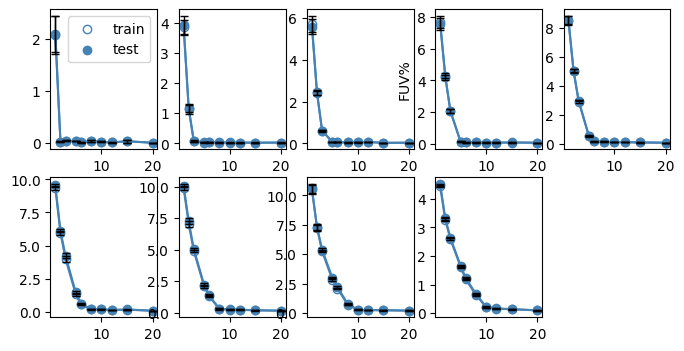

In [11]:
NT=np.arange(2,11,1)
n_ori=100
n_trial = 5
glv_type="b"
sim_type="fixed"
model_index=1
fig,axes=plt.subplots(2,5,figsize=(8,4))
axes=axes.flat
for i,n_target in enumerate(NT):
    ax=axes[i]
    n_background = n_ori-n_target
    data_train=np.loadtxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_train.txt")
    data_test=np.loadtxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    N_EBD = data_train[0,:]
    for j,data in enumerate([data_train,data_test]):
        FUV = data[1:,:]
        mean_FUV = np.mean(FUV,axis=0)
        std_FUV = np.std(FUV,axis=0,ddof=1)
        se_FUV = std_FUV/np.sqrt(n_trial)
        mfc = 'white' if j==0 else 'steelblue'
        ax.scatter(N_EBD,mean_FUV,facecolor=mfc,edgecolor='steelblue')
        ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
        ax.plot(N_EBD,mean_FUV,c='steelblue')
ax=axes[0]
ax.scatter([],[],facecolor='white',edgecolor='steelblue',label='train')
ax.scatter([],[],facecolor='steelblue',edgecolor='steelblue',label='test')
ax.legend()
ax=axes[3]
ax.set_xlabel("n$_{embedding}$")
ax.set_ylabel("FUV%")
axes[-1].set_visible(False)

Now fit the FUV-embedding relationship to an exponential threshold function

[2.14606902 4.18710855 0.01717044]
[3.69737487 1.78722114 0.03335347]
[5.57135708 1.12912882 0.03601276]
[6.14692657 0.91005429 0.081966  ]
[7.27957883 0.73952263 0.10083109]
[9.14007233 0.52820028 0.13313625]
[11.07405539  0.40959604  0.17014497]
[12.51993058  0.3447748   0.2069077 ]
[13.8245844   0.27531166  0.13250624]


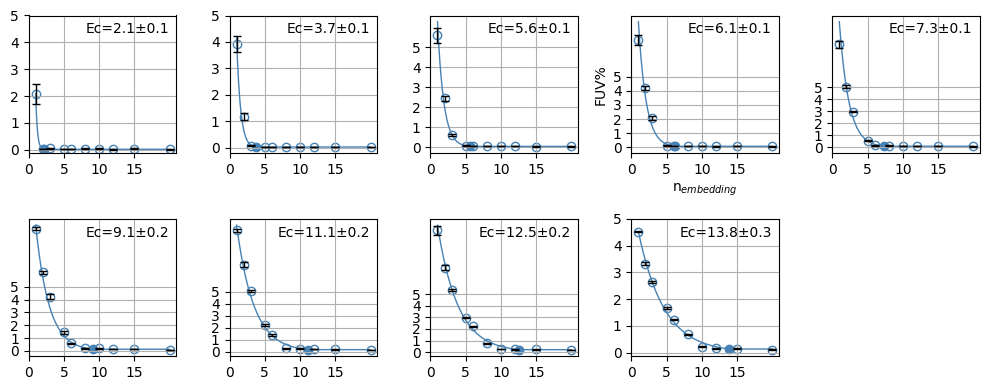

In [15]:
NT=np.arange(2,11,1)
n_ori=100
n_trial = 5
glv_type="b"
sim_type="fixed"
model_index=3
fig,axes=plt.subplots(2,5,figsize=(10,4))
axes=axes.flat
Ec_data = np.zeros((3,len(NT)))
Ec_data[0,:]=NT
for i,n_target in enumerate(NT):
    ax=axes[i]
    n_background = n_ori-n_target
    data=np.loadtxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    N_EBD=data[0,:]
    FUV = data[1:,:]
    mean_FUV = np.mean(FUV,axis=0)
    std_FUV = np.std(FUV,axis=0,ddof=1)
    se_FUV = std_FUV/np.sqrt(n_trial)
    ax.scatter(N_EBD,mean_FUV,fc='white',ec='steelblue')
    ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
    
    popt, pcov = curve_fit(y_exp, N_EBD, mean_FUV, sigma=se_FUV, absolute_sigma=True, p0=(n_target, 1, 0.1))
    print(popt)
    Ec = popt[0]
    param_errors = np.sqrt(np.diag(pcov))# estimate the standard errors of the fitted parameters
    Ec_se = param_errors[0]
    Ec_data[1,i]=Ec
    Ec_data[2,i]=Ec_se
    y_Ec = y_exp(np.array([Ec]),*popt)
    ax.scatter(Ec,y_Ec,c='steelblue')
    xx=np.linspace(1,20,1000)
    yy=y_exp(xx,*popt)
    ax.plot(xx,yy,color="steelblue",linewidth=1)
    
    ax.text(x=0.95,y=0.95,s="Ec=%1.1f±%1.1f"%(Ec,Ec_se),ha="right",va="top",transform=ax.transAxes)
    if i==3:
        ax.set_xlabel("n$_{embedding}$")
        ax.set_ylabel("FUV%")
    ax.set_xticks(np.arange(0,20,5))
    ax.set_yticks(np.arange(6))
    ax.grid(True)
axes[-1].set_visible(False)
fig.tight_layout()
np.savetxt(f"./saved_data/transformer/{glv_type}gLV/Ec_{glv_type}gLV_model{model_index}_{sim_type}.txt",Ec_data)

fixed bgLV Community 1
Slope            : 1.415 ± 0.017 (SE)
Intercept        : -0.665 ± 0.080 (SE)
t-statistic      : 82.09  (dof = 7)
p-value (slope≠0): 1.05e-11
Weighted R²      : 0.991
fixed bgLV Community 2
Slope            : 1.415 ± 0.017 (SE)
Intercept        : -0.665 ± 0.080 (SE)
t-statistic      : 82.09  (dof = 7)
p-value (slope≠0): 1.05e-11
Weighted R²      : 0.991
fixed bgLV Community 3
Slope            : 1.415 ± 0.017 (SE)
Intercept        : -0.665 ± 0.080 (SE)
t-statistic      : 82.09  (dof = 7)
p-value (slope≠0): 1.05e-11
Weighted R²      : 0.991


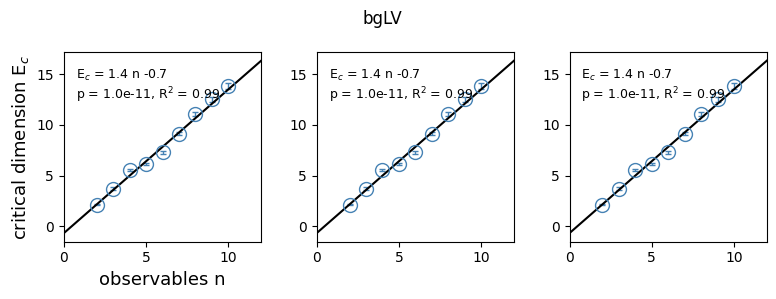

In [17]:
from scipy.optimize import curve_fit
from scipy.stats import t

# Linear model
def linear_model(x, a, b):
    return a * x + b

glv_type="b"
sim_type="fixed"
fig,axes = plt.subplots(1,3,figsize=(8,3))
axes=axes.flat
for i,model_index in enumerate([1,2,3]):
    ax=axes[i]
    data = np.loadtxt(f"./saved_data/transformer/{glv_type}gLV/Ec_{glv_type}gLV_model{model_index}_{sim_type}.txt")
    # Extract x, y, and CI bounds
    N_TG = data[0,:]
    Ec = data[1,:]
    Ec_se = data[2,:]
    Ec_se[Ec_se>10]=np.inf
    ax.errorbar(N_TG,Ec,Ec_se,marker="o",c='steelblue',mfc="None",capsize=2,lw=0,markersize=10,
                    elinewidth=1)
    
    # Weighted fit using standard errors
    popt, pcov = curve_fit(linear_model, N_TG, Ec, sigma=Ec_se, absolute_sigma=True)
    slope, intercept = popt
    slope_se, intercept_se = np.sqrt(np.diag(pcov))

    # residuals and total sums of squares
    y_pred = linear_model(N_TG, slope, intercept)
    SS_res = np.sum(((Ec - y_pred)/Ec_se)**2)     # weighted residual SS
    SS_tot = np.sum(((Ec - np.average(Ec, weights=1/Ec_se**2))/Ec_se)**2)
    
    R2 = 1 - SS_res / SS_tot
    
    # Compute t-statistic and p-value
    dof = len(N_TG) - 2
    t_stat = slope / slope_se
    p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))
    
    # Generate fit line and CI band
    x_fit = np.linspace(0, 12, 100)
    y_fit = linear_model(x_fit, slope, intercept)

    ax.plot(x_fit,y_fit,c="k")
    ax.set_xlim([0, 12])
    
    # ----- formatted report ---------------------------------------------------
    print(f"{sim_type} {glv_type}gLV Community {model_index}")
    report = (
        f"Slope            : {slope:.3f} ± {slope_se:.3f} (SE)\n"
        f"Intercept        : {intercept:.3f} ± {intercept_se:.3f} (SE)\n"
        f"t-statistic      : {t_stat:.2f}  (dof = {dof})\n"
        f"p-value (slope≠0): {p_value:.3g}\n"
        f"Weighted R²      : {R2:.3f}"
    )

    print(report)

    # Format regression equation
    txt = (f"E$_c$ = {slope:.1f} n {intercept:+.1f}\n"
       f"p = {p_value:.1e}, R$^2$ = {R2:.2f}")
    ax.text(x=0.06, y=0.75, s=txt, transform=ax.transAxes, fontsize=9)
    #ax.text(x=0.11,y=0.85,s=txt,transform=ax.transAxes, fontsize=10)
ax=axes[0]
ax.set_xlabel("observables n", fontsize=13)
ax.set_ylabel("critical dimension E$_c$", fontsize=13)
fig.suptitle(f"{glv_type}gLV")
fig.tight_layout()

### Random Background Case

In [4]:
n_ori=100

glv_type="b"
sim_type="random"

#NT=np.arange(1,11,1)
NT = np.arange(9,11,1)
N_EBD = [1, 2, 3, 5, 6, 8, 10, 12, 15, 20, 25, 30, 40, 50]
for i,n_target in enumerate(NT):
    n_background=n_ori-n_target
    for model_index in [1,2,3]:
        data_train = np.zeros((6,len(N_EBD)))
        data_train[0,:] = N_EBD
        data_test = np.zeros((6,len(N_EBD)))
        data_test[0,:] = N_EBD
        X_train, X_test = get_data(n_background, n_target, glv_type, sim_type, model_index)
        batch_train = torch.Tensor(X_train).float()
        batch_test = torch.Tensor(X_test).float()
        for trial in range(1,6,1):
            for j,n_embedding in enumerate(N_EBD):
                model = TransformerAutoEncoder(n_target,n_embedding)
                model.to("cuda:0");
                model.load_state_dict(
                    torch.load(
                        f"./transformer/{glv_type}gLV/I{model_index}/{sim_type}_B{n_background}_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True
                        ))
                mse_train,r2_train=get_error(model,batch_train)
                data_train[trial,j]=(1-r2_train)*100
                mse_test,r2_test=get_error(model,batch_test)
                data_test[trial,j]=(1-r2_test)*100
        save_dir = f"./saved_data/transformer/{glv_type}gLV/I{model_index}"
        os.makedirs(save_dir, exist_ok=True)
        np.savetxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_train.txt", data_train)
        np.savetxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt", data_test)
        print("model %i; target %i finished"%(model_index,n_target,))

model 1; target 9 finished
model 2; target 9 finished
model 3; target 9 finished
model 1; target 10 finished
model 2; target 10 finished
model 3; target 10 finished


Text(0, 0.5, 'FUV%')

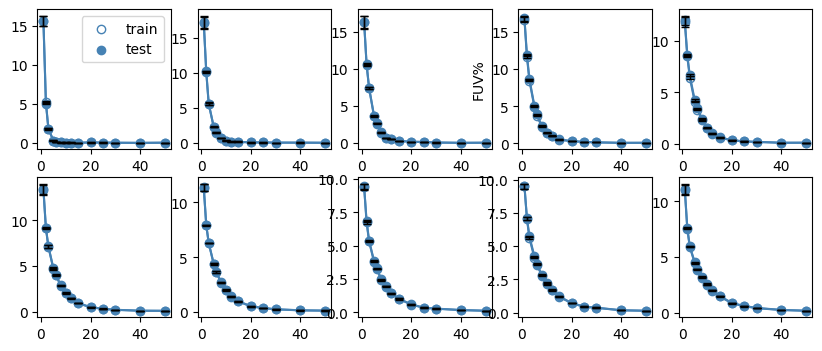

In [5]:
NT=np.arange(1,11,1)
n_ori=100
n_trial = 5
glv_type="b"
sim_type="random"
model_index=1
fig,axes=plt.subplots(2,5,figsize=(10,4))
axes=axes.flat
for i,n_target in enumerate(NT):
    ax=axes[i]
    n_background = n_ori-n_target
    save_dir = f"./saved_data/transformer/{glv_type}gLV/I{model_index}"
    data_train=np.loadtxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_train.txt")
    data_test=np.loadtxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    N_EBD = data_train[0,:]
    for j,data in enumerate([data_train,data_test]):
        FUV = data[1:,:]
        mean_FUV = np.mean(FUV,axis=0)
        std_FUV = np.std(FUV,axis=0,ddof=1)
        se_FUV = std_FUV/np.sqrt(n_trial)
        mfc = 'white' if j==0 else 'steelblue'
        ax.scatter(N_EBD,mean_FUV,facecolor=mfc,edgecolor='steelblue')
        ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
        ax.plot(N_EBD,mean_FUV,c='steelblue')
ax=axes[0]
ax.scatter([],[],facecolor='white',edgecolor='steelblue',label='train')
ax.scatter([],[],facecolor='steelblue',edgecolor='steelblue',label='test')
ax.legend()
ax=axes[3]
ax.set_xlabel("n$_{embedding}$")
ax.set_ylabel("FUV%")

[8.22612411 0.84656509 0.04237322]
[13.29725566  0.42931203  0.06825783]
[17.95671972  0.29525757  0.1206006 ]
[19.03388031  0.25696821  0.1246441 ]
[24.21286516  0.21229656  0.08765034]
[22.73175326  0.1926708   0.17425304]
[28.46384984  0.15599781  0.15958604]
[29.0083652   0.14752278  0.20068919]
[33.24491361  0.12274168  0.22100064]
[32.14168375  0.12726331  0.13396067]


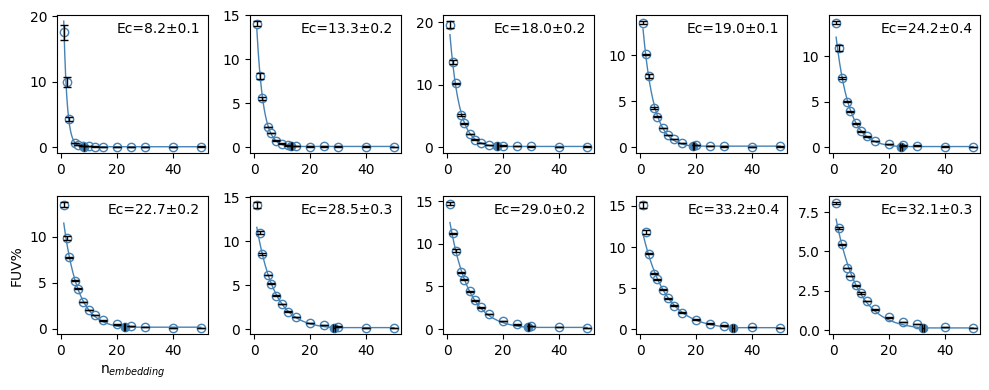

In [13]:
NT=np.arange(1,11,1)
n_ori=100
n_trial = 5
glv_type="b"
sim_type="random"
model_index=3
fig,axes=plt.subplots(2,5,figsize=(10,4))
axes=axes.flat
Ec_data = np.zeros((3,len(NT)))
Ec_data[0,:]=NT
for i,n_target in enumerate(NT):
    ax=axes[i]
    n_background = n_ori-n_target
    save_dir = f"./saved_data/transformer/{glv_type}gLV/I{model_index}"
    data=np.loadtxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    N_EBD=data[0,:]
    FUV = data[1:,:]
    mean_FUV = np.mean(FUV,axis=0)
    std_FUV = np.std(FUV,axis=0,ddof=1)
    se_FUV = std_FUV/np.sqrt(n_trial)
    ax.scatter(N_EBD,mean_FUV,fc='white',ec='steelblue')
    ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
    
    popt, pcov = curve_fit(y_exp, N_EBD, mean_FUV, sigma=se_FUV, absolute_sigma=True, 
                           p0=(10+n_target, 0.2, 0.2))
    print(popt)
    Ec = popt[0]
    param_errors = np.sqrt(np.diag(pcov))# estimate the standard errors of the fitted parameters
    Ec_se = param_errors[0]
    Ec_data[1,i]=Ec
    Ec_data[2,i]=Ec_se
    y_Ec = y_exp(np.array([Ec]),*popt)
    ax.scatter(Ec,y_Ec,c='steelblue')
    ax.errorbar(Ec,y_Ec,xerr=Ec_se,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
    xx=np.linspace(1,50,1000)
    yy=y_exp(xx,*popt)
    ax.plot(xx,yy,color="steelblue",linewidth=1)
    
    ax.text(x=0.95,y=0.95,s="Ec=%1.1f±%1.1f"%(Ec,Ec_se),ha="right",va="top",transform=ax.transAxes)
    if i==5:
        ax.set_xlabel("n$_{embedding}$")
        ax.set_ylabel("FUV%")
fig.tight_layout()
np.savetxt(f"./saved_data/transformer/{glv_type}gLV/Ec_{glv_type}gLV_model{model_index}_{sim_type}.txt",Ec_data)

random bgLV Community 1
Slope            : 2.769 ± 0.024 (SE)
Intercept        : 5.952 ± 0.113 (SE)
t-statistic      : 113.02  (dof = 8)
p-value (slope≠0): 4.2e-14
Weighted R²      : 0.945
random bgLV Community 2
Slope            : 2.491 ± 0.027 (SE)
Intercept        : 7.719 ± 0.150 (SE)
t-statistic      : 93.23  (dof = 8)
p-value (slope≠0): 1.95e-13
Weighted R²      : 0.934
random bgLV Community 3
Slope            : 2.772 ± 0.023 (SE)
Intercept        : 7.132 ± 0.113 (SE)
t-statistic      : 123.04  (dof = 8)
p-value (slope≠0): 2.13e-14
Weighted R²      : 0.958


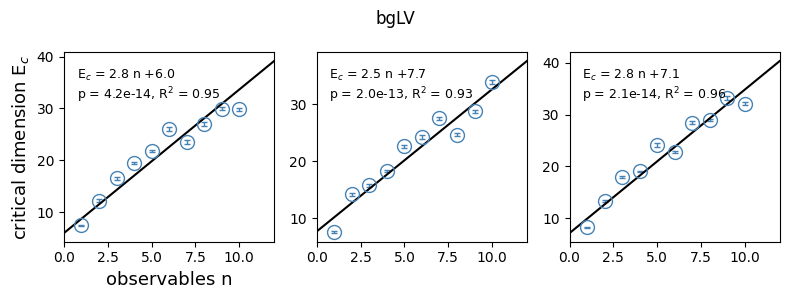

In [14]:
from scipy.optimize import curve_fit
from scipy.stats import t

# Linear model
def linear_model(x, a, b):
    return a * x + b

glv_type="b"
sim_type="random"
fig,axes = plt.subplots(1,3,figsize=(8,3))
axes=axes.flat
for i,model_index in enumerate([1,2,3]):
    ax=axes[i]
    data = np.loadtxt(f"./saved_data/transformer/{glv_type}gLV/Ec_{glv_type}gLV_model{model_index}_{sim_type}.txt")
    # Extract x, y, and CI bounds
    N_TG = data[0,:]
    Ec = data[1,:]
    Ec_se = data[2,:]
    ax.errorbar(N_TG,Ec,Ec_se,marker="o",c='steelblue',mfc="None",capsize=2,lw=0,markersize=10,
                    elinewidth=1)
    
    # Weighted fit using standard errors
    popt, pcov = curve_fit(linear_model, N_TG, Ec, sigma=Ec_se, absolute_sigma=True)
    slope, intercept = popt
    slope_se, intercept_se = np.sqrt(np.diag(pcov))
    
    # Compute t-statistic and p-value
    dof = len(N_TG) - 2
    t_stat = slope / slope_se
    p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))

    # residuals and total sums of squares
    y_pred = linear_model(N_TG, slope, intercept)
    SS_res = np.sum(((Ec - y_pred)/Ec_se)**2)     # weighted residual SS
    SS_tot = np.sum(((Ec - np.average(Ec, weights=1/Ec_se**2))/Ec_se)**2)
    
    R2 = 1 - SS_res / SS_tot
    
    # Generate fit line and CI band
    x_fit = np.linspace(0, 12, 100)
    y_fit = linear_model(x_fit, slope, intercept)

    ax.plot(x_fit,y_fit,c="k")
    ax.set_xlim([0, 12])
    
    # ----- formatted report ---------------------------------------------------
    print(f"{sim_type} {glv_type}gLV Community {model_index}")
    report = (
        f"Slope            : {slope:.3f} ± {slope_se:.3f} (SE)\n"
        f"Intercept        : {intercept:.3f} ± {intercept_se:.3f} (SE)\n"
        f"t-statistic      : {t_stat:.2f}  (dof = {dof})\n"
        f"p-value (slope≠0): {p_value:.3g}\n"
        f"Weighted R²      : {R2:.3f}"
    )

    print(report)


    # Format regression equation
    txt = (f"E$_c$ = {slope:.1f} n {intercept:+.1f}\n"
       f"p = {p_value:.1e}, R$^2$ = {R2:.2f}")
    ax.text(x=0.06, y=0.75, s=txt, transform=ax.transAxes, fontsize=9)
    #ax.text(x=0.11,y=0.85,s=txt,transform=ax.transAxes, fontsize=10)
ax=axes[0]
ax.set_xlabel("observables n", fontsize=13)
ax.set_ylabel("critical dimension E$_c$", fontsize=13)
fig.suptitle(f"{glv_type}gLV")
fig.tight_layout()

# Dispersal Model with fixed background

In [6]:
n_ori=100

glv_type="d"
sim_type="fixed"

NT = np.arange(2,9,1)
N_EBD = [1,2,3,5,6,8,10,12,15,20,30]
for i,n_target in enumerate(NT):
    n_background=n_ori-n_target
    for model_index in [1,]:
        data_train = np.zeros((6,len(N_EBD)))
        data_train[0,:] = N_EBD
        data_test = np.zeros((6,len(N_EBD)))
        data_test[0,:] = N_EBD
        X_train, X_test = get_data(n_background, n_target, glv_type, sim_type, model_index)
        batch_train = torch.Tensor(X_train).float()
        batch_test = torch.Tensor(X_test).float()
        for trial in range(1,6,1):
            for j,n_embedding in enumerate(N_EBD):
                model = TransformerAutoEncoder(n_target,n_embedding)
                model.to("cuda:0");
                model.load_state_dict(
                    torch.load(
                        f"./transformer/{glv_type}gLV/I{model_index}/{sim_type}_B{n_background}_T{n_target}_E{n_embedding}_trial{trial}.pth",weights_only=True
                        ))
                mse_train,r2_train=get_error(model,batch_train)
                data_train[trial,j]=(1-r2_train)*100
                mse_test,r2_test=get_error(model,batch_test)
                data_test[trial,j]=(1-r2_test)*100
        save_dir = f"./saved_data/transformer/{glv_type}gLV/I{model_index}"
        os.makedirs(save_dir, exist_ok=True)
        np.savetxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_train.txt", data_train)
        np.savetxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt", data_test)
        print("model %i; target %i finished"%(model_index,n_target,))

model 1; target 2 finished
model 1; target 3 finished
model 1; target 4 finished
model 1; target 5 finished
model 1; target 6 finished
model 1; target 7 finished
model 1; target 8 finished


Text(0, 0.5, 'FUV%')

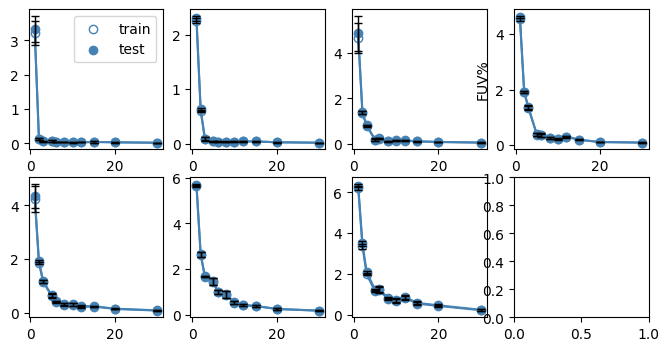

In [7]:
NT=np.arange(2,9,1)
n_ori=100
n_trial = 5
glv_type="d"
sim_type="fixed"
model_index=1
fig,axes=plt.subplots(2,4,figsize=(8,4))
axes=axes.flat
for i,n_target in enumerate(NT):
    ax=axes[i]
    n_background = n_ori-n_target
    save_dir = f"./saved_data/transformer/{glv_type}gLV/I{model_index}"
    data_train=np.loadtxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_train.txt")
    data_test=np.loadtxt(f"{save_dir}/reconstruction_B{n_background}_T{n_target}_{glv_type}gLV_{sim_type}_test.txt")
    N_EBD = data_train[0,:]
    for j,data in enumerate([data_train,data_test]):
        FUV = data[1:,:]
        mean_FUV = np.mean(FUV,axis=0)
        std_FUV = np.std(FUV,axis=0,ddof=1)
        se_FUV = std_FUV/np.sqrt(n_trial)
        mfc = 'white' if j==0 else 'steelblue'
        ax.scatter(N_EBD,mean_FUV,facecolor=mfc,edgecolor='steelblue')
        ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
        ax.plot(N_EBD,mean_FUV,c='steelblue')
ax=axes[0]
ax.scatter([],[],facecolor='white',edgecolor='steelblue',label='train')
ax.scatter([],[],facecolor='steelblue',edgecolor='steelblue',label='test')
ax.legend()
ax=axes[3]
ax.set_xlabel("n$_{embedding}$")
ax.set_ylabel("FUV%")